In the tutorial notebook, we followed the data analysis for a full sector of TESS data. Below is the same procedure for a set of subsectors.

In [1]:
import glob
from figures import *

root = '/home/ktp9/TESSNeptune24/tess-ice-giants/'
data_dir = root + 'final_data/'

bps, pps = 40, 10
bpps_dir = f'bps{bps}_pps{pps}/'

subdir = data_dir + f'subsectors/{bpps_dir}'

## intitialize the list of sectors 
planet_sectors = ["u42", "u43", "u44", "n42", "n70"]
sample_cadences = np.array([10/60, 10/60, 10/60, 10/60, (200/60)/60]) # in hours

supfigdir = root + "figures/supplementary/" + bpps_dir



Separate each light curve into ten ~equal subsectors (~5-10 mins)

In [2]:
# load in the light curves
lc_dir = data_dir + "light_curves/" + bpps_dir
lc_list = []
for sector in planet_sectors:
    lc_list.append(np.load(lc_dir + f'{sector}_lcs.npz'))

In [ ]:
# ~10 min runtime

from subsectors import * 
from fullsector import nyquist_from_cadence

max_freq_arr = nyquist_from_cadence(sample_cadences / 24)

total_segs = 10

times = [sector['time'] for sector in lc_list]
fluxes = [sector['orbit_corrected'] for sector in lc_list]
result = split_data(times, fluxes, 
                    max_freq_arr, freq_array_size=10000,
                    m=50, total_segs=total_segs, 
                    bootstrap=True,
                    verbose=True)

(subtimes, subfluxes, subfreqs, subpower, subfap, subpeaks, subpeakfap) = result

Processing dataset 0
Processing dataset 1
Processing dataset 2
Processing dataset 3
Processing dataset 4


In [4]:

os.makedirs(subdir, exist_ok=True)
print(f"saving to: {subdir}")
np.savez(subdir + 'subsectors.npz', 
         subtimes=np.array(subtimes, dtype=object), 
         subfluxes=np.array(subfluxes, dtype=object),
         subfreqs=np.array(subfreqs, dtype=object), 
         subpower=np.array(subpower, dtype=object), 
         subfap=np.array(subfap, dtype=object),
         subpeaks=np.array(subpeaks, dtype=object), 
         subpeakfap=np.array(subpeakfap, dtype=object),
         allow_pickle=True)

saving to: /home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/bps40_pps10/


In [2]:
subsectors = np.load(subdir + 'subsectors.npz', allow_pickle=True)
subtimes = subsectors['subtimes']
subfluxes = subsectors['subfluxes']
subfreqs = np.array(subsectors['subfreqs'], dtype=float)
subpower = subsectors['subpower']
subfap = subsectors['subfap']
subpeakfap = subsectors['subpeakfap']

In [18]:
from bootstrap import bootstrap_peak_periods

nsec, nsub = subtimes.shape

bootstrap_results = np.empty((nsec, nsub), dtype=object)
for sec in range(nsec):
    print(f"Bootstrapping sector {sec+1}/{nsec}...")
    min_period=1/max_freq_arr[sec]

    for sub in range(nsub):
        print(f"Bootstrapping subsector {sub+1}/{nsub}...")
        max_period = (subtimes[sec, sub][-1] - subtimes[sec, sub][0])/2
        print(f"min, max period: {min_period, max_period}")

        peak_periods = bootstrap_peak_periods(subtimes[sec, sub], 
                                              subfluxes[sec, sub], 
                                              fap_level=0.01, 
                                              n_bootstraps=10000, 
                                              boot_percent=0.8, 
                                              min_period=min_period, 
                                              max_period=max_period, 
                                              n_freqs=1000, 
                                              figdir=supfigdir, 
                                              sds=planet_sectors[sec] + f"_ss{sub}",
                                              n_plot=100)
        bootstrap_results[sec, sub] = peak_periods

Bootstrapping sector 1/5...
Bootstrapping subsector 1/10...
min, max period: (0.013888888888888888, 0.9723171042278409)


100%|██████████| 10000/10000 [00:50<00:00, 199.07it/s]


Bootstrapping subsector 2/10...
min, max period: (0.013888888888888888, 0.9723131230566651)


100%|██████████| 10000/10000 [00:49<00:00, 202.13it/s]


Bootstrapping subsector 3/10...
min, max period: (0.013888888888888888, 0.9688381112646312)


...

100%|██████████| 10000/10000 [01:06<00:00, 150.53it/s]


Bootstrapping subsector 9/10...
min, max period: (0.00462962962962963, 1.025417995173484)


100%|██████████| 10000/10000 [01:20<00:00, 124.42it/s]


Bootstrapping subsector 10/10...
min, max period: (0.00462962962962963, 1.0254169015679508)


100%|██████████| 10000/10000 [01:03<00:00, 156.77it/s]


In [20]:
np.savez(subdir + 'bootstrap_results.npz', bootstrap_results=bootstrap_results, allow_pickle=True)

In [3]:
bootstrap_results = np.load(subdir + 'bootstrap_results.npz', allow_pickle=True)['bootstrap_results']
print(bootstrap_results.shape)

(5, 10)


Processing sector 0/5...


Processing sector 1/5...
Processing sector 2/5...
Processing sector 3/5...
Processing sector 4/5...


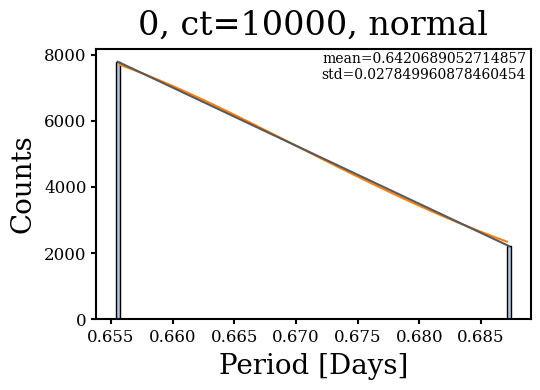

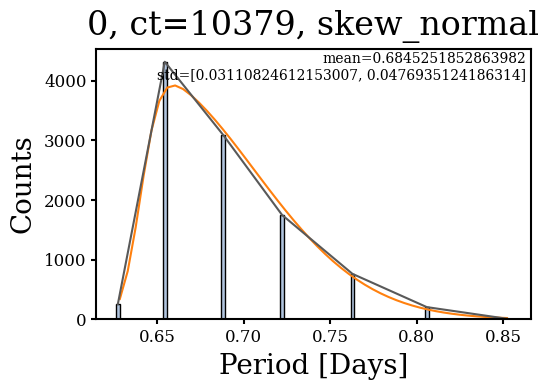

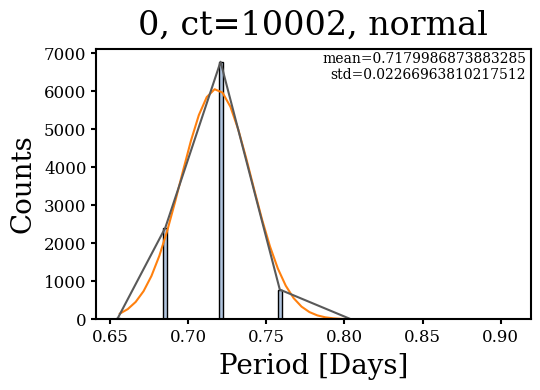

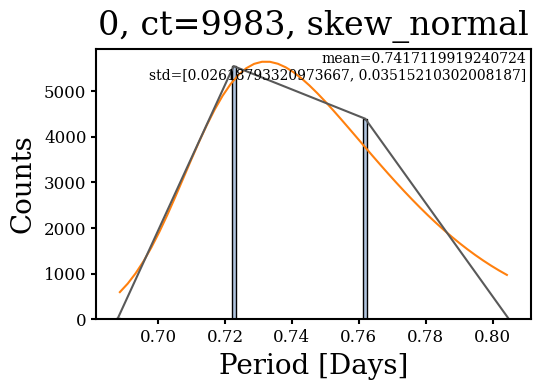

<Figure size 500x400 with 0 Axes>

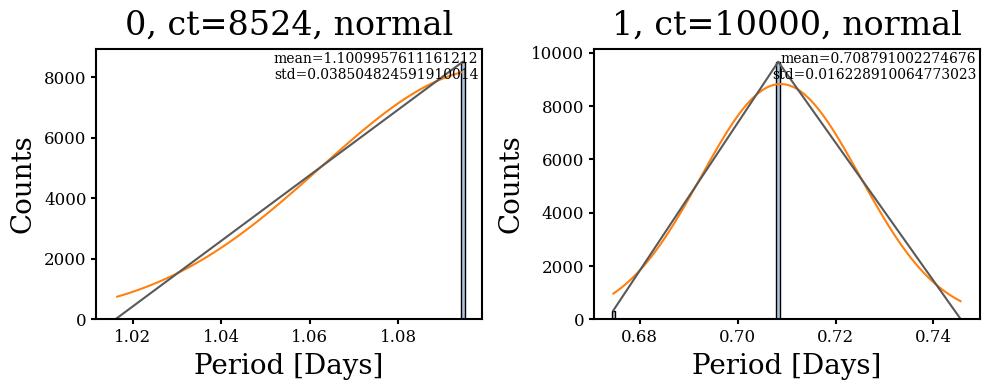

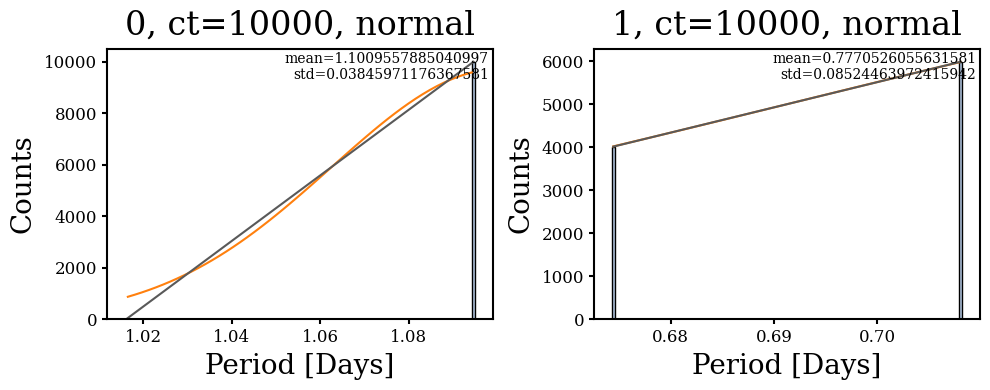

<Figure size 500x400 with 0 Axes>

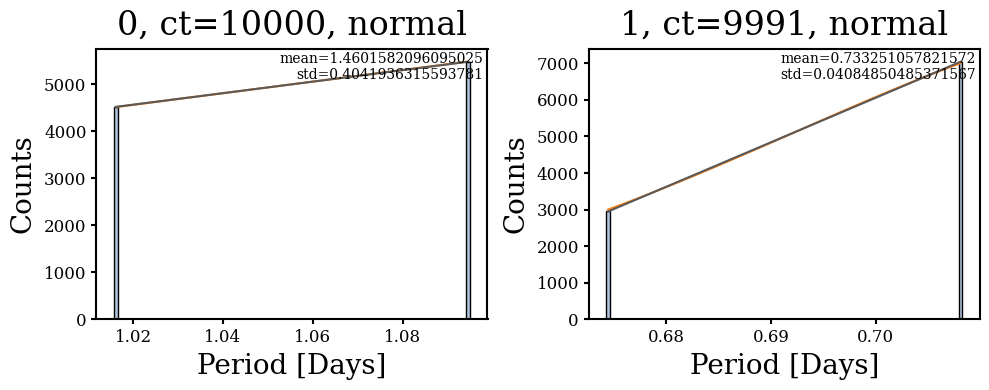

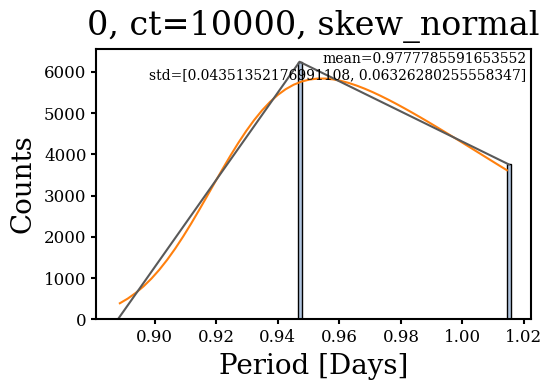

<Figure size 500x400 with 0 Axes>

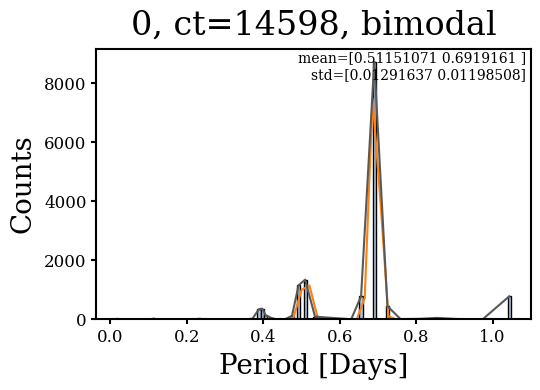

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

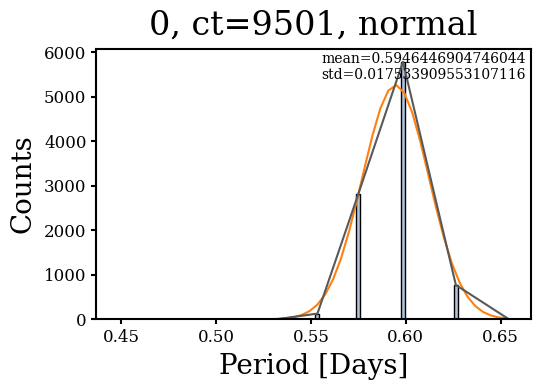

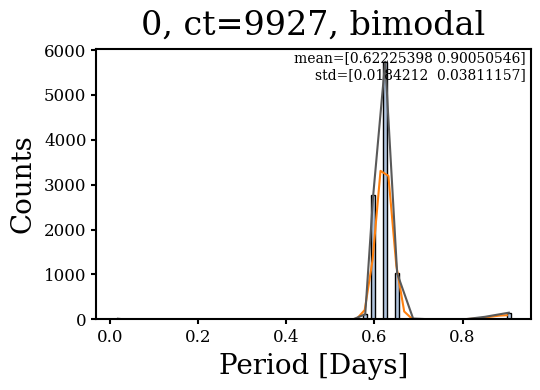

<Figure size 500x400 with 0 Axes>

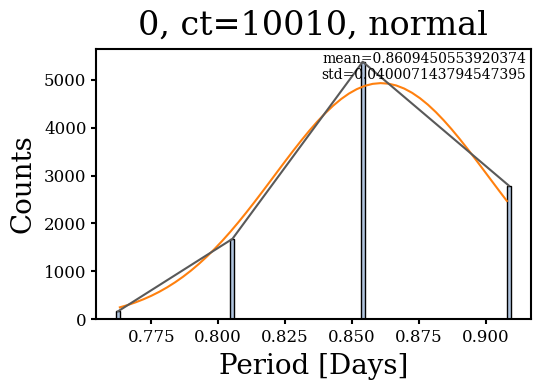

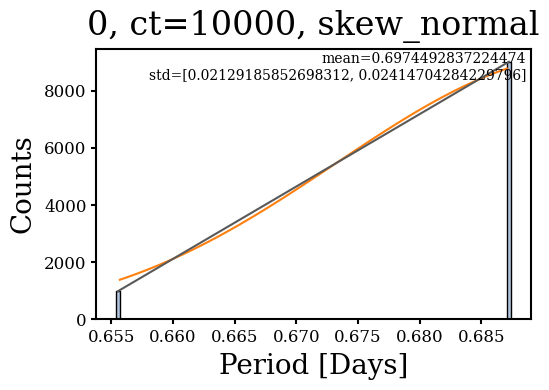

<Figure size 500x400 with 0 Axes>

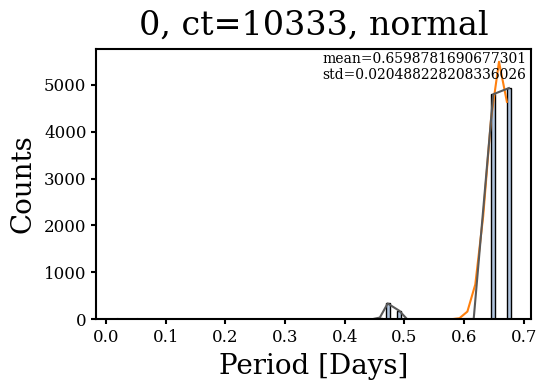

<Figure size 500x400 with 0 Axes>

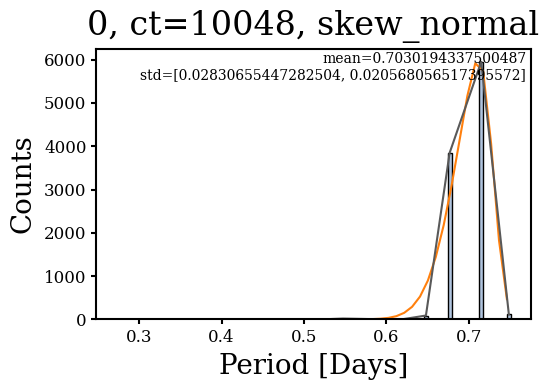

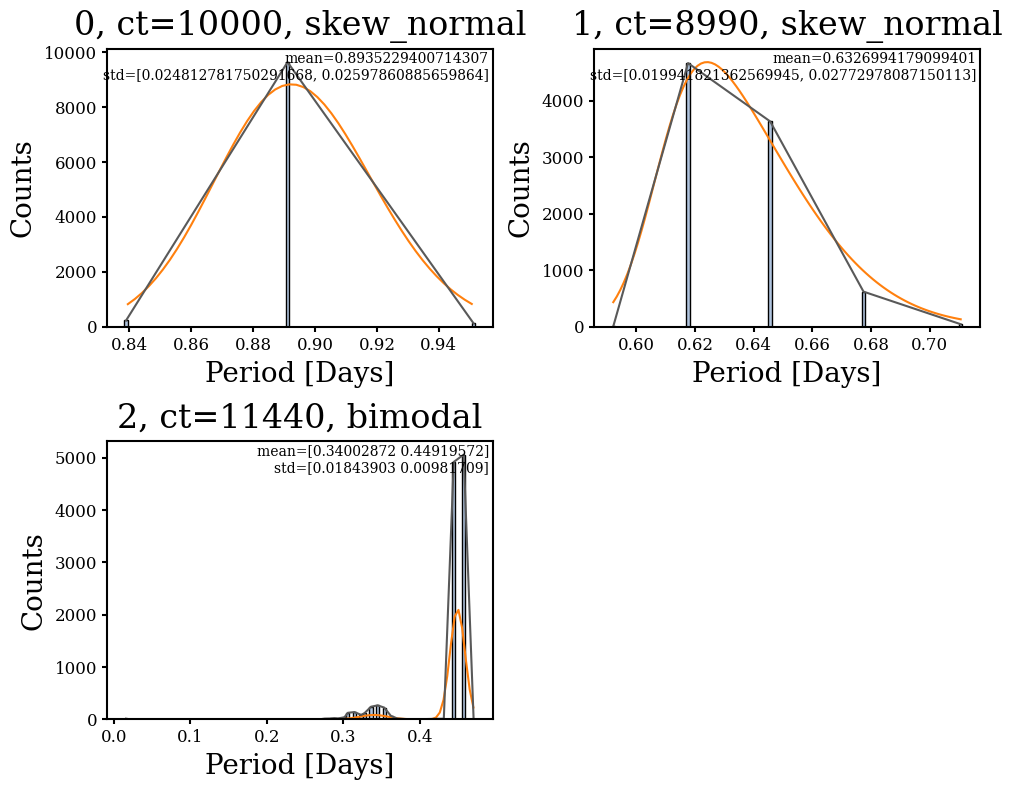

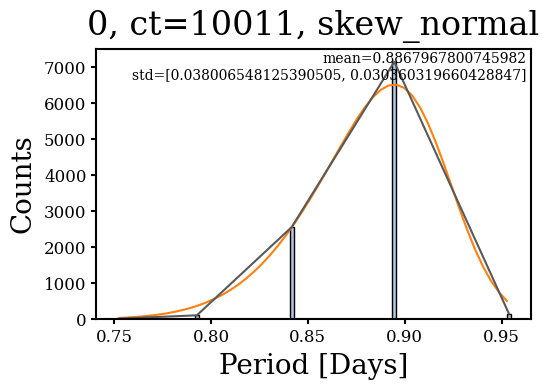

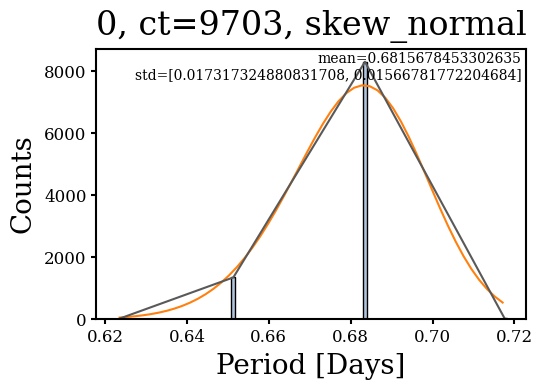

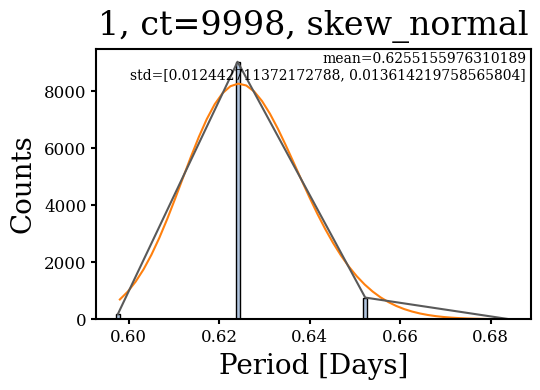

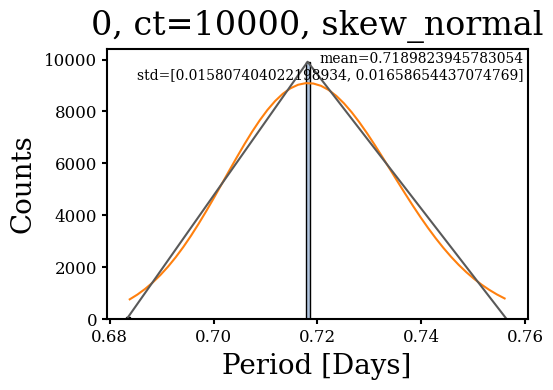

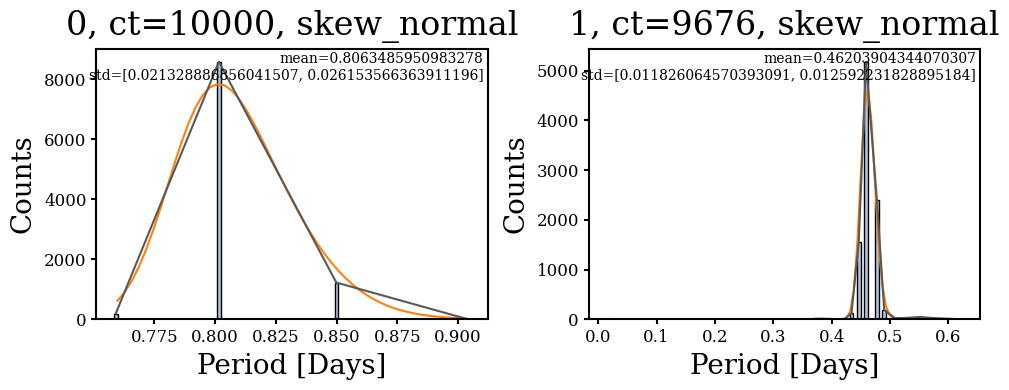

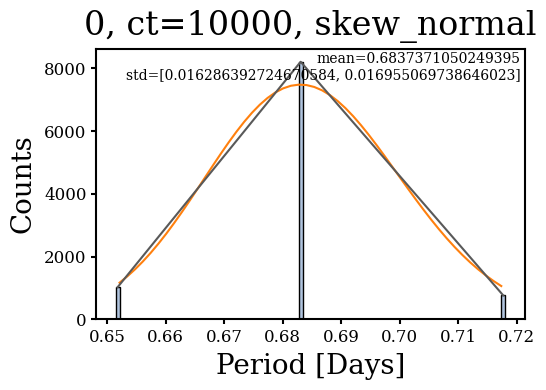

<Figure size 500x400 with 0 Axes>

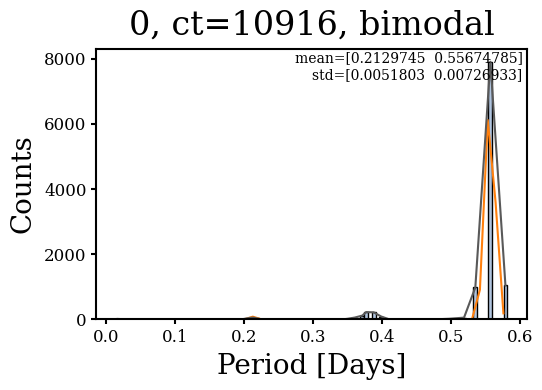

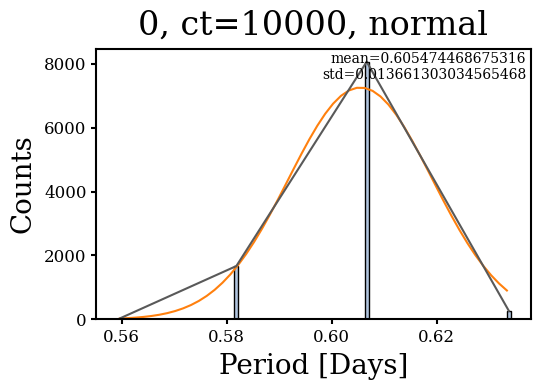

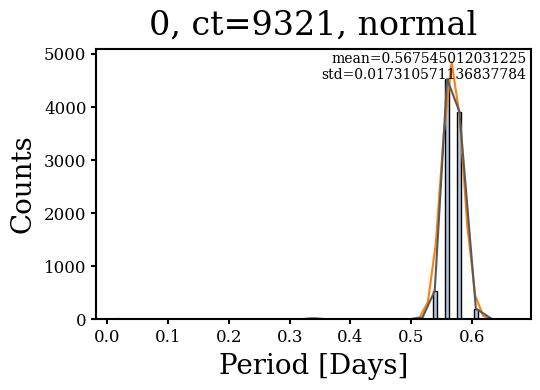

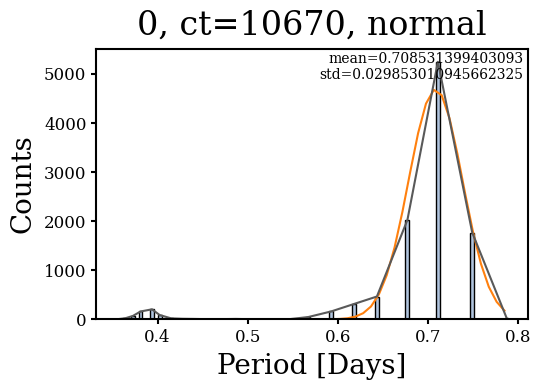

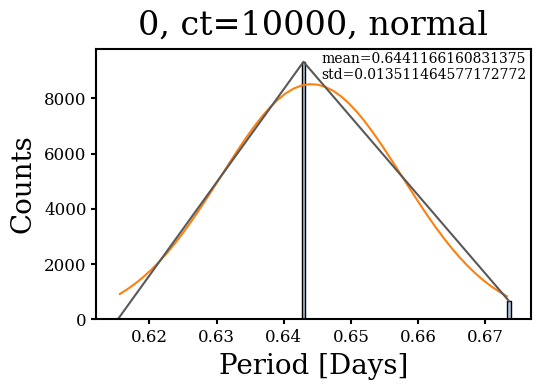

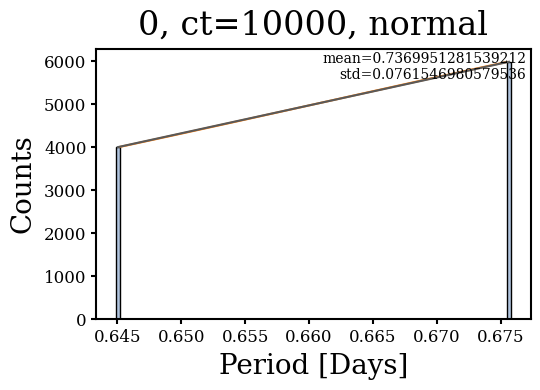

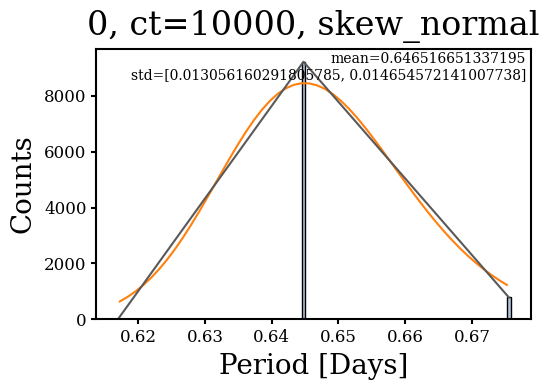

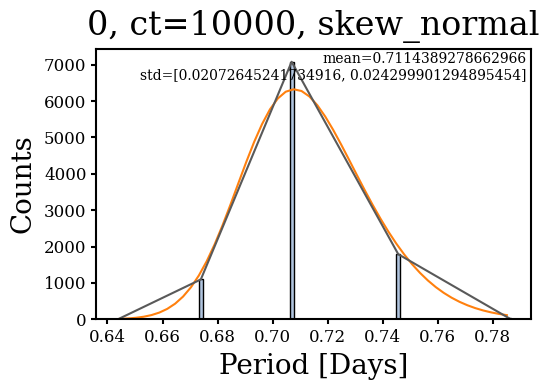

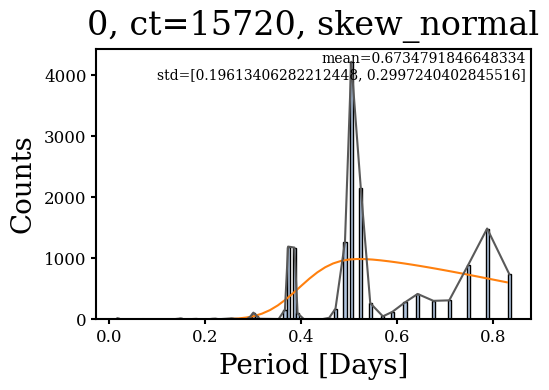

<Figure size 500x400 with 0 Axes>

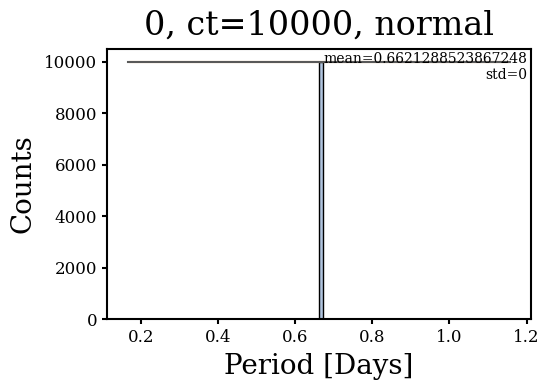

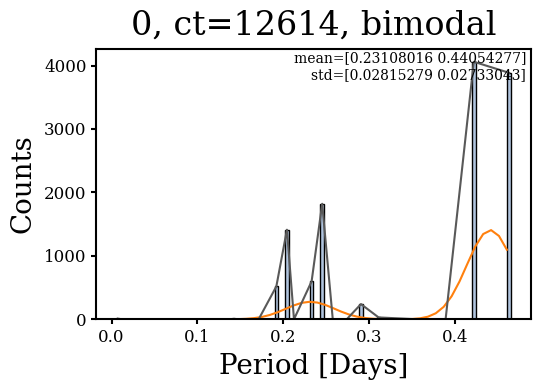

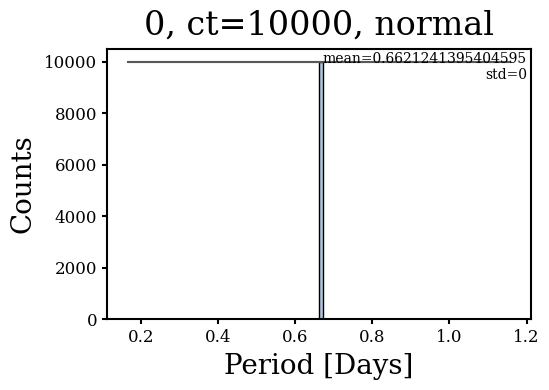

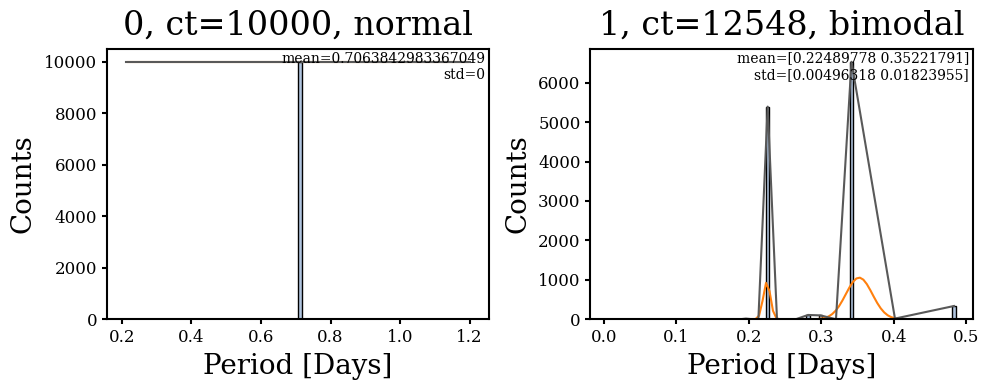

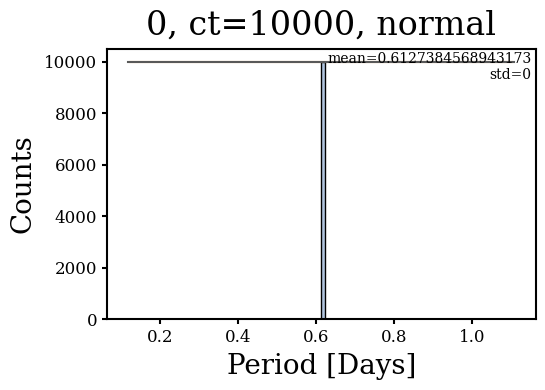

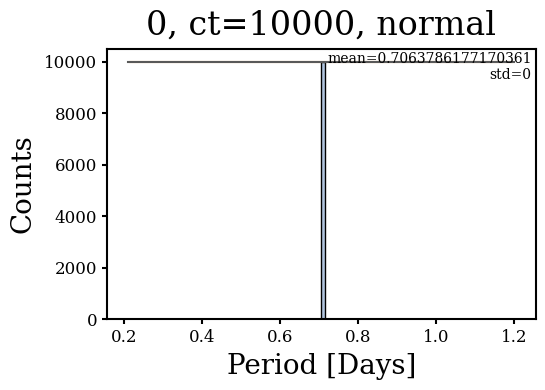

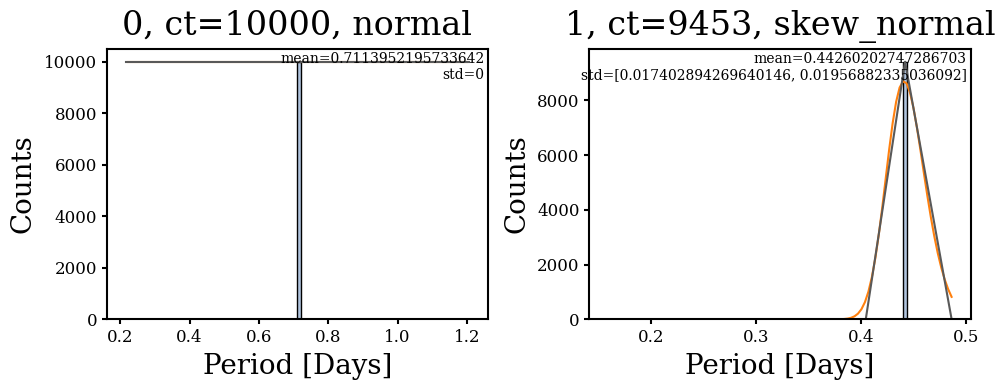

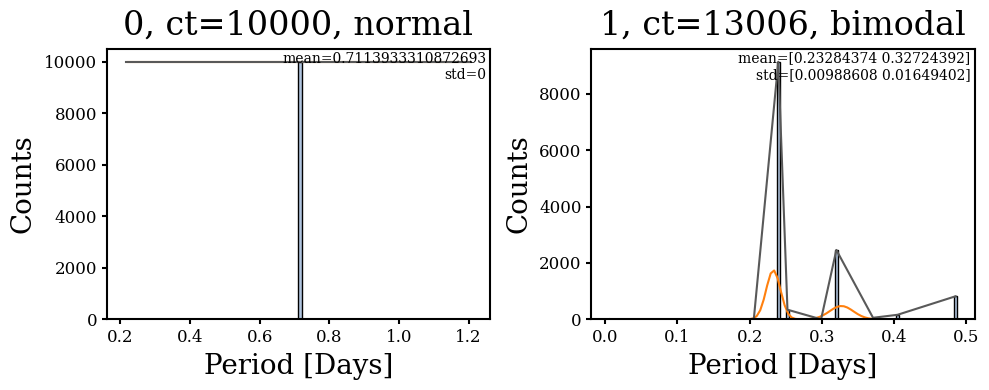

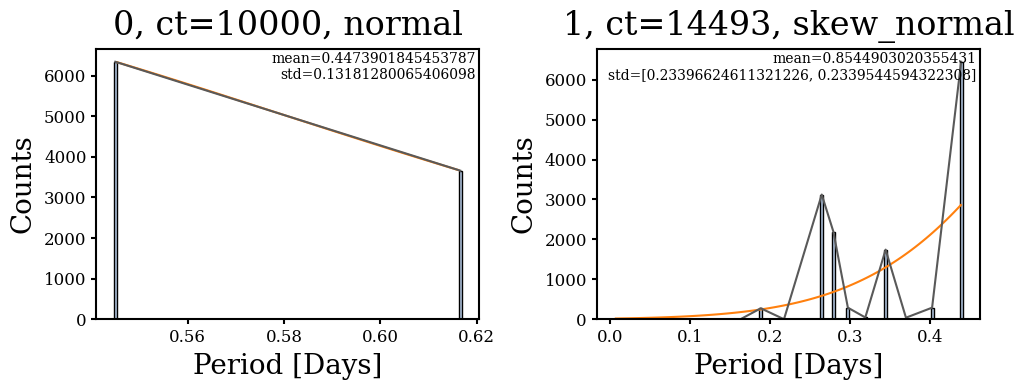

In [4]:
from bootstrap import cluster_peaks
nsec, nsub = bootstrap_results.shape
cluster_results = np.empty((nsec, nsub), dtype=object)
for sec in range(nsec):
    print(f"Processing sector {sec}/{nsec}...")
    for sub in range(nsub):
        peaks = bootstrap_results[sec, sub]
        labels, all_means, all_stds = cluster_peaks(peaks, 
                                                    sds=planet_sectors[sec] + f"_ss{sub}",
                                                    eps=0.1, 
                                                    n_bootstraps=10000,
                                                    pass_frac=0.8, n_bins=50,
                                                    figdir=supfigdir + "clusters/")
        
        cluster_results[sec, sub] = (labels, all_means, all_stds)

np.savez(subdir + 'cluster_results.npz', cluster_results=cluster_results, allow_pickle=True)

In [3]:
from wind_equations import *
cluster_results = np.load(subdir + 'cluster_results.npz', allow_pickle=True)['cluster_results']
nsec, nsub = cluster_results.shape

ur_wind_eqns = [sromovsky2012_odd_N, sromovsky2012_odd_S, sromovsky2015_N, sromovsky2015_S]
# ur_wind_eqn_errs = [sigma_sromovsky2012_odd_N, sigma_sromovsky2012_odd_S, sigma_sromovsky2015_N, sigma_sromovsky2015_S]
ur_wind_eqn_errs = [sigma_uranus_model(wind_eqn) for wind_eqn in ur_wind_eqns]
ur_wind_eqn_strings = ["sromovsky2012_odd_N", "sromovsky2012_odd_S", "sromovsky2015_N", "sromovsky2015_S"]

nep_wind_eqns = [sromovsky1993_four, sromovsky1993_six, tollefson2013_kp, tollefson2014_kp]
nep_wind_eqn_errs = [sromovsky1993_four_err, sromovsky1993_six_err, tollefson2013_kp_err, tollefson2014_kp_err]
nep_wind_eqn_strings = ["sromovsky1993_four", "sromovsky1993_six", "tollefson2013_kp", "tollefson2014_kp"]

# planet data
uRe = 25559 * 1000
uRp = 24973 * 1000
uP = 17.247864
uRe_err = 4000
uRp_err = 20000
uP_err = 0.00001

nRe = 24764 * 1000
nRp = 24341 * 1000
nP = 15.9663
nRe_err = 15000
nRp_err = 30000
nP_err = 0.0002

reperr12 = 0.088 # degrees/h, pg. 11 of Sromovsky+ 2012c
reperr15 = 0.147 / 24 # 0.147 degrees/day, pg. 11 of Sromovsky+ 2015
reperrs = [reperr12, reperr12, reperr15, reperr15]

In [4]:
from mcmc import *

mcmc_results = np.empty((nsec, nsub))
for i, sec in enumerate(range(nsec)):
    mcmc_root = subdir + f"{planet_sectors[i]}/"

    for sub in range(nsub):
        labels, all_means, all_stds = cluster_results[sec, sub]
        sector_data = {}
        sector_data['matched_means'] = all_means
        sector_data['matched_stds'] = all_stds
        
        # if len(all_means) > 0:
        #     sector_data['matched_means'].extend(all_means)
        #     sector_data['matched_stds'].extend(all_stds)
        
        # for key in sector_data:
        #     sector_data[key] = np.array(sector_data[key])

        # print(f"Type of sector_data['matched_means']: {type(sector_data['matched_means'])}")
        # print(f"Dtype: {sector_data['matched_means'].dtype if hasattr(sector_data['matched_means'], 'dtype') else 'No dtype'}")
        if planet_sectors[i][0] == "u":
            print("Uranus sector: ", planet_sectors[i], "sub", sub)
            save_mcmc(ur_wind_eqns, ur_wind_eqn_errs, sector_data,
                        uRe, uRp, uP, uRe_err, uRp_err, uP_err, 
                        ur_wind_eqn_strings, f"subsector{sub}", mcmc_root + "mcmc/", reperrs=reperrs)
        elif planet_sectors[i][0] == "n":
            print("Neptune sector: ", planet_sectors[i], "sub", sub)
            save_mcmc(nep_wind_eqns, nep_wind_eqn_errs, sector_data, 
                        nRe, nRp, nP, nRe_err, nRp_err, nP_err, 
                        nep_wind_eqn_strings, f"subsector{sub}", mcmc_root + "mcmc/")


Uranus sector:  u42 sub 0
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.369822
Minimum f with at least one intersection: 1.369822
Using minimum frequency of 1.3605305096908973 for wind equation sromovsky2012_odd_N
matched means [0.6420689052714857]
matched stds [0.027849960878460454]
Processing wind equation: sromovsky2012_odd_N
Frequency, error: 1.557465237437671 [0.06755559]


100%|██████████| 5000/5000 [01:18<00:00, 63.46it/s]


Median latitude (deg): 49.84761407785277
Std 16.00336584492097
appended phi_deg of median 49.84761407785277
Using minimum frequency of 1.3605305096908973 for wind equation sromovsky2012_odd_S
matched means [0.6420689052714857]
matched stds [0.027849960878460454]
Processing wind equation: sromovsky2012_odd_S
Frequency, error: 1.557465237437671 [0.06755559]


100%|██████████| 5000/5000 [01:20<00:00, 62.39it/s]


Median latitude (deg): 49.75480064911625
Std 15.809751568405277
appended phi_deg of median 49.75480064911625
Using minimum frequency of 1.369822244200759 for wind equation sromovsky2015_N
matched means [0.6420689052714857]
matched stds [0.027849960878460454]
Processing wind equation: sromovsky2015_N
Frequency, error: 1.557465237437671 [0.06755559]


...

100%|██████████| 5000/5000 [01:21<00:00, 61.33it/s]


Median latitude (deg): 25.38491109266581
Std 11.227688365571323
Total Median latitude (deg): 25.694428390508715
Total Std 11.010458289990238
appended phi_deg of median 25.694428390508715
Using minimum frequency of 1.369822244200759 for wind equation sromovsky2015_N
matched means [0.6974492837224474]
matched stds [[0.02129185852698312, 0.02414704284229796]]
Processing wind equation: sromovsky2015_N
Frequency, error: 1.4337960097439197 [0.04377119 0.04964079]
Skewed distribution. Taking lower chain


  4%|▍         | 197/5000 [00:02<01:08, 70.53it/s]Traceback (most recent call last):
  File "/home/ktp9/anaconda3/envs/TESSNeptune24/lib/python3.11/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ktp9/TESSNeptune24/tess-ice-giants/frequency_analysis/mcmc.py", line 35, in log_probability
    return lp + log_likelihood(phi, f_obs, sigma_f, model_eqn, sigma_eqn, freq_eqn)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ktp9/TESSNeptune24/tess-ice-giants/frequency_analysis/mcmc.py", line 21, in log_likelihood
    return -0.5 * np.sum(((data - model) / sigma_func(phi, f_obs, f_err))**2)
                                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ktp9/TESSNeptune24/tess-ice-giants/frequency_analysis/wind_equations.py", line 377, in equation
    return np.sqrt(sigma_u(phi, f, sigma_f)**2 + sigma_m(phi

emcee: Exception while calling your likelihood function:
  params: [0.46906391]
  args: (1.4337960097439197, 0.04377118524387109, <function U_PHI.<locals>.equation at 0x7f86daf0ad40>, <function sigma.<locals>.equation at 0x7f86daf09940>, <function RHS.<locals>.equation at 0x7f86daf0b880>)
  kwargs: {}
  exception:


KeyboardInterrupt: 

In [8]:
i = 5

file = f"/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/bps40_pps10/u42/mcmc/subsector{i}_phi_distributions.npz"

data = np.load(file, allow_pickle=True)

print(data['phi_distributions'])

[[[28.307476068212527 28.123700559259618 28.293009504709755 ...
   28.149660249146052 27.9910405312164 28.09884124601637]]]


In [2]:
import glob
import os
from tqdm import tqdm 
import re

from mcmc import fit_all_distributions

import glob

from mcmc import fit_all_distributions

subroot = root + "subsectors"

for sector in planet_sectors:
    secsubroot = subdir + sector
    mcmc_list = glob.glob(secsubroot + "/mcmc/*")
    mcmc_list.sort(key=lambda x: int(re.search(r'subsector(\d+)', x).group(1)))
    for i, phi_file in enumerate(mcmc_list):
        print(phi_file)
        print(sector, i)

        phi_dist = np.load(phi_file, allow_pickle=True)
        phi_data = phi_dist['phi_distributions']

        print(phi_data.shape)
        # for data in phi_data:
        #     if len(data) > 0:
        #         print("mean, std", np.median(data), np.std(data))
        #     else:
        #         continue
        all_latitudes, all_standard_devs = fit_all_distributions(phi_dist["phi_distributions"], 
                                                                        phi_dist["wind_eqn_strings"], 
                                                                        verbose=False,
                                                                        truncbound=None, 
                                                                        sds=sector, 
                                                                        figdir=supfigdir + "subposteriors/")

        print(all_latitudes, all_standard_devs)

        if os.path.exists(secsubroot + "/latitudes/") == False:
            os.makedirs(secsubroot + "/latitudes/")
        np.savez(secsubroot + "/latitudes/" + f"{sector}_sub{i}_latitude_solutions.npz", 
                    lat=np.array(all_latitudes, dtype=object), 
                    std=np.array(all_standard_devs, dtype=object), 
                    allow_pickle=True) 


/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/bps40_pps10/u42/mcmc/subsector0_phi_distributions.npz
u42 0
(1, 0)
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/bps40_pps10/u42/mcmc/subsector1_phi_distributions.npz
u42 1
(1, 0)
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/bps40_pps10/u42/mcmc/subsector2_phi_distributions.npz
u42 2
(1, 0)
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/bps40_pps10/u42/mcmc/subsector3_phi_distributions.npz
u42 3
(1, 0)
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/bps40_pps10/u42/mcmc/subsector4_phi_distributions.npz
u42 4
(1, 0)
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-

In [5]:
from mcmc import *


cluster_results = np.load(subdir + 'cluster_results.npz', allow_pickle=True)['cluster_results']
nsec, nsub = cluster_results.shape

mcmc_results = np.empty((nsec, nsub))
for i, sec in enumerate(range(nsec)):
    mcmc_root = subdir + f"{planet_sectors[i]}/"

    for sub in range(nsub):
        labels, all_means, all_stds = cluster_results[sec, sub]
        sector_data = {}
        sector_data['matched_means'] = all_means
        sector_data['matched_stds'] = all_stds
        
        # if len(all_means) > 0:
        #     sector_data['matched_means'].extend(all_means)
        #     sector_data['matched_stds'].extend(all_stds)

        print(sec, sub, all_means, all_stds)
        
        # for key in sector_data:
        #     sector_data[key] = np.array(sector_data[key])

        # print(f"Type of sector_data['matched_means']: {type(sector_data['matched_means'])}")
        # print(f"Dtype: {sector_data['matched_means'].dtype if hasattr(sector_data['matched_means'], 'dtype') else 'No dtype'}")
        # if planet_sectors[i][0] == "u":
        #     print("Uranus sector: ", planet_sectors[i], "sub", sub)
        #     save_mcmc(ur_wind_eqns, ur_wind_eqn_errs, sector_data,
        #                 uRe, uRp, uP, uRe_err, uRp_err, uP_err, 
        #                 ur_wind_eqn_strings, f"subsector{sub}", mcmc_root + "mcmc/", reperrs=reperrs)
        # elif planet_sectors[i][0] == "n":
        #     print("Neptune sector: ", planet_sectors[i], "sub", sub)
        #     save_mcmc(nep_wind_eqns, nep_wind_eqn_errs, sector_data, 
        #                 nRe, nRp, nP, nRe_err, nRp_err, nP_err, 
        #                 nep_wind_eqn_strings, f"subsector{sub}", mcmc_root + "mcmc/")


0 0 [0.6420689052714857] [0.027849960878460454]
0 1 [0.6845251852863982] [[0.03110824612153007, 0.0476935124186314]]
0 2 [0.7179986873883285] [0.02266963810217512]
0 3 [0.7417119919240724] [[0.02618793320973667, 0.03515210302008187]]
0 4 [] []
0 5 [1.1009957611161212, 0.708791002274676] [0.038504824591910014, 0.016228910064773023]
0 6 [1.1009557885040997, 0.7770526055631581] [0.03845971176367581, 0.08524463972415942]
0 7 [] []
0 8 [1.4601582096095025, 0.733251057821572] [0.4041936315593781, 0.04084850485371567]
0 9 [0.9777785591653552] [[0.04351352176991108, 0.06326280255558347]]
1 0 [] []
1 1 [0.6919160986472606] [0.011985078949949763]
1 2 [] []
1 3 [] []
1 4 [0.5946446904746044] [0.017533909553107116]
1 5 [0.6222539835119578] [0.018421203360754767]
1 6 [] []
1 7 [0.8609450553920374] [0.040007143794547395]
1 8 [0.6974492837224474] [[0.02129185852698312, 0.02414704284229796]]
1 9 [] []
2 0 [0.6598781690677301] [0.020488228208336026]
2 1 [] []
2 2 [0.7030194337500487] [[0.02830655447282